
import os
from pathlib import Path
import shutil

root_dir = Path("/mnt/bigdisk1/AllieSpangaro/Morphology_Replicative_Age_Project/MRC-5_MAX_SUM_PROJ/20250328_rep05")  # Change to your root directory

for dirpath, dirnames, filenames in os.walk(root_dir, topdown=False):
    for dirname in dirnames:
        if ".tif" in dirname:
            full_path = Path(dirpath) / dirname
            if not any(full_path.iterdir()):
                print(f"Removing empty directory: {full_path}")
                shutil.rmtree(full_path)
            else:
                print(f"Skipped non-empty directory: {full_path}")

# Stitching using ImageJ plugins


In [1]:
from matplotlib import pyplot as plt
import cv2 as cv
import numpy as np
from wellstitching import *
from pathlib import Path
from PIL import Image
import numpy as np

input_folder = "/mnt/bigdisk1/AllieSpangaro/Morphology_Replicative_Age_Project/MRC-5_MAX_SUM_PROJ/20250328_rep05"
output_base = "/mnt/bigdisk1/AllieSpangaro/Morphology_Replicative_Age_Project/MRC-5_MAX_SUM_PROJ/20250328_rep05"

file_list = load_sorted_directory_list(input_folder)
nchannels = get_nchannels(file_list)
grouped_files_by_channel = group_files_by_channel(file_list, nchannels)

grouped_files_by_well = group_files_by_well(file_list, 40, nchannels)
#print_grouped_files(grouped_files_by_well)
block_a_files, block_b_files = get_well_stitching_block_paths(grouped_files_by_well)

Well 1: Block A sorted order:
    MAX_ch1-r02c01f22.tif
    MAX_ch2-r02c01f22.tif
    MAX_ch3-r02c01f22.tif
    MAX_ch4-r02c01f22.tif
    MAX_ch1-r02c01f23.tif
    MAX_ch2-r02c01f23.tif
    MAX_ch3-r02c01f23.tif
    MAX_ch4-r02c01f23.tif
    MAX_ch1-r02c01f24.tif
    MAX_ch2-r02c01f24.tif
    MAX_ch3-r02c01f24.tif
    MAX_ch4-r02c01f24.tif
    MAX_ch1-r02c01f25.tif
    MAX_ch2-r02c01f25.tif
    MAX_ch3-r02c01f25.tif
    MAX_ch4-r02c01f25.tif
    MAX_ch1-r02c01f01.tif
    MAX_ch2-r02c01f01.tif
    MAX_ch3-r02c01f01.tif
    MAX_ch4-r02c01f01.tif
    MAX_ch1-r02c01f26.tif
    MAX_ch2-r02c01f26.tif
    MAX_ch3-r02c01f26.tif
    MAX_ch4-r02c01f26.tif
    MAX_ch1-r02c01f27.tif
    MAX_ch2-r02c01f27.tif
    MAX_ch3-r02c01f27.tif
    MAX_ch4-r02c01f27.tif
    MAX_ch1-r02c01f28.tif
    MAX_ch2-r02c01f28.tif
    MAX_ch3-r02c01f28.tif
    MAX_ch4-r02c01f28.tif
    MAX_ch1-r02c01f29.tif
    MAX_ch2-r02c01f29.tif
    MAX_ch3-r02c01f29.tif
    MAX_ch4-r02c01f29.tif
    MAX_ch1-r02c01f30.tif
    MAX_

In [2]:
print_grouped_files(block_a_files)
test_well = grouped_files_by_well[0]
test_well_a = block_a_files[0]
test_well_b = block_b_files[0]
test_well_ch2 = [file for file in test_well if "ch2-" in str(file)]

output_folder_test = os.path.join(output_base,"test_stitching")
os.makedirs(output_folder_test, exist_ok=True)
#print_grouped_files(block_a_files)

print(test_well_ch2)


 Group 1 of 72
 MAX_ch1-r02c01f22.tif
 MAX_ch2-r02c01f22.tif
 MAX_ch3-r02c01f22.tif
 MAX_ch4-r02c01f22.tif
 MAX_ch1-r02c01f23.tif
 MAX_ch2-r02c01f23.tif
 MAX_ch3-r02c01f23.tif
 MAX_ch4-r02c01f23.tif
 MAX_ch1-r02c01f24.tif
 MAX_ch2-r02c01f24.tif
 MAX_ch3-r02c01f24.tif
 MAX_ch4-r02c01f24.tif
 MAX_ch1-r02c01f25.tif
 MAX_ch2-r02c01f25.tif
 MAX_ch3-r02c01f25.tif
 MAX_ch4-r02c01f25.tif
 MAX_ch1-r02c01f01.tif
 MAX_ch2-r02c01f01.tif
 MAX_ch3-r02c01f01.tif
 MAX_ch4-r02c01f01.tif
 MAX_ch1-r02c01f26.tif
 MAX_ch2-r02c01f26.tif
 MAX_ch3-r02c01f26.tif
 MAX_ch4-r02c01f26.tif
 MAX_ch1-r02c01f27.tif
 MAX_ch2-r02c01f27.tif
 MAX_ch3-r02c01f27.tif
 MAX_ch4-r02c01f27.tif
 MAX_ch1-r02c01f28.tif
 MAX_ch2-r02c01f28.tif
 MAX_ch3-r02c01f28.tif
 MAX_ch4-r02c01f28.tif
 MAX_ch1-r02c01f29.tif
 MAX_ch2-r02c01f29.tif
 MAX_ch3-r02c01f29.tif
 MAX_ch4-r02c01f29.tif
 MAX_ch1-r02c01f30.tif
 MAX_ch2-r02c01f30.tif
 MAX_ch3-r02c01f30.tif
 MAX_ch4-r02c01f30.tif
 MAX_ch1-r02c01f31.tif
 MAX_ch2-r02c01f31.tif
 MAX_ch3-r02c01f31

In [3]:
def copy_to_blocks(grouped_files_by_well, block_a_files, block_b_files): 
    
    for idx, groups in enumerate(grouped_files_by_well):
        if isinstance(groups,Path):
            filepath = groups
            filename = filepath.name
            parent_filepath = filepath.parent
            plate_location = get_plate_location(filepath)
            location_path = os.path.join(output_folder_test, plate_location)
            #print(filename,str(parent_filepath),plate_location,location_path)
            
            if idx==0:
                os.makedirs(location_path, exist_ok=True)
                folder_a_path = os.path.join(location_path, "Block_A")
                folder_b_path = os.path.join(location_path, "Block_B")
                os.makedirs(folder_a_path, exist_ok=True)
                os.makedirs(folder_b_path, exist_ok=True)
        else:
            filepath = groups[idx]
            filename = filepath.name
            parent_filepath = filepath.parent
            plate_location = get_plate_location(filepath)
            location_base_folder = os.path.join(parent_filepath, plate_location)
            os.makedirs(location_base_folder, exist_ok=True)
        
            folder_a_path = os.path.join(location_base_folder, "Block_A")
            folder_b_path = os.path.join(location_base_folder, "Block_B")
            #Create the new folders if they don't exist
            os.makedirs(folder_a_path, exist_ok=True)
            os.makedirs(folder_b_path, exist_ok=True)

        #loop thru all files in grouped by well
        if isinstance(groups,Path):
            if filepath in block_a_files:
                #shutil.copy2(filepath, folder_a_path)
                print(f"Copied {filename} to {folder_a_path}")
            elif filepath in block_b_files:
                #shutil.copy2(filepath, folder_b_path)
                print(f"Copied {filename} to {folder_b_path}")
        else: 
            for file in groups:
                if os.path.exists(file):
                    if file in block_a_files[idx]:
                        shutil.copy2(file, folder_a_path)
                        print(f"Copied {filename} to {folder_a_path}")
                    elif file in block_b_files[idx]:
                        shutil.copy2(file, folder_b_path)
                        print(f"Copied {filename} to {folder_b_path}")
                else:
                    print(f"Warning: {filename} not found in {filename}")
    
    print("\nFile organization complete!")
    
copy_to_blocks(test_well, test_well_a, test_well_b)

Copied MAX_ch1-r02c01f01.tif to /mnt/bigdisk1/AllieSpangaro/Morphology_Replicative_Age_Project/MRC-5_MAX_SUM_PROJ/20250328_rep05/test_stitching/r02c01f01/Block_A
Copied MAX_ch2-r02c01f01.tif to /mnt/bigdisk1/AllieSpangaro/Morphology_Replicative_Age_Project/MRC-5_MAX_SUM_PROJ/20250328_rep05/test_stitching/r02c01f01/Block_A
Copied MAX_ch3-r02c01f01.tif to /mnt/bigdisk1/AllieSpangaro/Morphology_Replicative_Age_Project/MRC-5_MAX_SUM_PROJ/20250328_rep05/test_stitching/r02c01f01/Block_A
Copied MAX_ch4-r02c01f01.tif to /mnt/bigdisk1/AllieSpangaro/Morphology_Replicative_Age_Project/MRC-5_MAX_SUM_PROJ/20250328_rep05/test_stitching/r02c01f01/Block_A
Copied MAX_ch1-r02c01f02.tif to /mnt/bigdisk1/AllieSpangaro/Morphology_Replicative_Age_Project/MRC-5_MAX_SUM_PROJ/20250328_rep05/test_stitching/r02c01f01/Block_B
Copied MAX_ch2-r02c01f02.tif to /mnt/bigdisk1/AllieSpangaro/Morphology_Replicative_Age_Project/MRC-5_MAX_SUM_PROJ/20250328_rep05/test_stitching/r02c01f01/Block_B
Copied MAX_ch3-r02c01f02.tif

In [22]:
import imagej,scyjava
#ij = imagej.init('sc.fiji:fiji')
scyjava.config.add_options('-Xmx6g')
ij = imagej.init('/home/mattiazzilab/Fiji')

 --- Setting global cache 
Global cache set to 6026 Mb, out of 12052 Mb available (50%)


[WARNING] 1 exceptions occurred during plugin discovery.
[WARN] Overriding action BDV - Set BDV window (biop)


ImageJ2 version: 2.16.0/Inactive
python_list: [4, 2, 3, 4]
java_list: [1, 2, 3, 4]
[INFO] Populating metadata


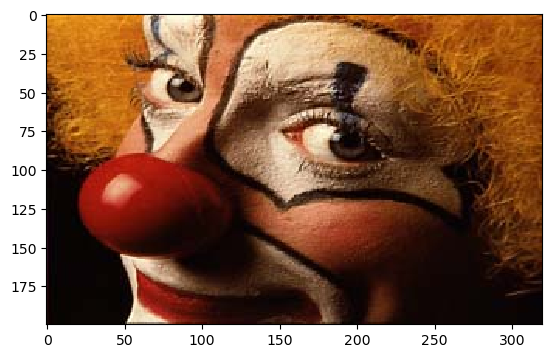

24104  MB available to Java


ImportError: The original ImageJ is not available in this environment. Use of original ImageJ macros is not possible. See: https://github.com/imagej/pyimagej/blob/main/doc/Initialization.md

In [31]:
print(f"ImageJ2 version: {ij.getVersion()}")
# create lists
python_list = [1, 2, 3, 4]
java_list = ij.py.to_java(python_list)

# modify one list
python_list[0] = 4

# check list contents
print(f"python_list: {python_list}\njava_list: {java_list}")

# Load an image.
image_url = 'https://imagej.net/images/clown.jpg'
jimage = ij.io().open(image_url)

# Convert the image from ImageJ2 to xarray, a package that adds
# labeled datasets to numpy (http://xarray.pydata.org/en/stable/).
image = ij.py.from_java(jimage)
ij.py.show(image, cmap='gray')

Runtime = scyjava.jimport('java.lang.Runtime')
print(Runtime.getRuntime().maxMemory() // (2**20), " MB available to Java")

HyperSphereShape = scyjava.jimport('net.imglib2.algorithm.neighborhood.HyperSphereShape')
radius = HyperSphereShape(5)

# load test image
ij.py.run_macro("""run("Blobs (25K)");""")
blobs = ij.WindowManager.getCurrentImage()
print(blobs)

# Display the image (backed by matplotlib).


macro = """
#@ String name
#@ int age
#@ String city
#@output Object greeting
greeting = "Hello " + name + ". You are " + age + " years old, and live in " + city + "."
"""
args = {
    'name': 'Chuckles',
    'age': 13,
    'city': 'Nowhere'
}
result = ij.py.run_macro(macro, args)
print(result.getOutput('greeting'))

In [11]:
#imp = ij.getImage();
ij.run("MIST", "gridwidth=5 gridheight=4 starttile=2 imagedir=/mnt/bigdisk1/AllieSpangaro/Morphology_Replicative_Age_Project/stitching/stitchtest_v2/block_b filenamepattern=MAX_ch2-r02c02f{pp}.tif filenamepatterntype=SEQUENTIAL gridorigin=UL assemblefrommetadata=false assemblenooverlap=false globalpositionsfile=[] numberingpattern=HORIZONTALCONTINUOUS startrow=0 startcol=0 extentwidth=5 extentheight=4 timeslices=0 istimeslicesenabled=false outputpath=/mnt/bigdisk1/AllieSpangaro/Morphology_Replicative_Age_Project/stitching/stitchtest_v2/block_b displaystitching=true outputfullimage=true outputmeta=true outputimgpyramid=false blendingmode=LINEAR blendingalpha=1.0 compressionmode=UNCOMPRESSED outfileprefix=testimg- unit=MICROMETER unitx=0.093 unity=0.093 programtype=AUTO numcputhreads=32 loadfftwplan=true savefftwplan=true fftwplantype=MEASURE fftwlibraryname=libfftw3 fftwlibraryfilename=libfftw3.dll planpath=/home/mattiazzilab/lib/fftw/fftPlans fftwlibrarypath=/home/mattiazzilab/lib/fftw stagerepeatability=0 horizontaloverlap=0.0 verticaloverlap=0.0 numfftpeaks=0 overlapuncertainty=NaN isusedoubleprecision=false isusebioformats=true issuppressmodelwarningdialog=false isenablecudaexceptions=false translationrefinementmethod=EXHAUSTIVE numtranslationrefinementstartpoints=16 headless=false loglevel=MANDATORY debuglevel=HELPFUL");
#IJ.run("Brightness/Contrast...");
#

AttributeError: 'net.imagej.ImageJ' object has no attribute 'run'